In [10]:
# ================================================================
#  PRÉDICTION DU DÉLAI DE VENTE — IMMOBILIER MAROCAIN
#  Cible : délai_vente (jours entre date_listing et date_sold)
#  Source : morocco-real-estate-listings.csv (enrichi)
#  Auteurs : Bounacer · Hiba · El Boti · Imrane | Mars 2026
#  ➜ Google Colab — exécuter cellule par cellule
# ================================================================

# ── INSTALLATION ─────────────────────────────────────────────────
# !pip install scikit-learn matplotlib seaborn pandas numpy scipy -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import random

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.inspection import permutation_importance

# Style global
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
})


In [8]:
import pandas as pd

df_raw = pd.read_excel('/content/drive/MyDrive/morocco-real-estate-enriched.xlsx')

# Manually set the header to the second row (index 1)
df_raw.columns = df_raw.iloc[1]
# Drop the first two rows (metadata and old header)
df_raw = df_raw[2:].reset_index(drop=True)
# Remove the name of the columns index
df_raw.columns.name = None

# Clean column names by stripping whitespace
df_raw.columns = df_raw.columns.str.strip()

# Rename columns to match the original simulation's expected names
df_raw = df_raw.rename(columns={
    'Type de bien': 'TYPE',
    'Transaction': 'TXN',
    'Ville': 'VILLE',
    'Quartier': 'QUARTIER',
    'Surface (m²)': 'SURF_M2',
    'Chambres': 'CHAMBRES',
    'Prix (MAD)': 'PRIX_MAD',
    'MAD/m²': 'MAD_M2',
    '📅 Date de mise en ligne': 'DATE_LISTING',
    '📅 Date de transaction': 'DATE_TRANSACTION',
    '📅 Date de vente (acte)': 'DATE_SOLD',
    '🔖 Statut': 'STATUS',
    '⏱ Délai de vente (jours)': 'DELAI_VENTE',
    'Source': 'SOURCE',
    'Vendeur': 'VENDEUR',
})

# Add missing 'ETAT' and 'STANDING' columns with default values
# These columns were generated in the simulation but are not in the provided Excel.
# Defaulting them to common values to allow the rest of the notebook to run.
if 'ETAT' not in df_raw.columns:
    df_raw['ETAT'] = 'Bon état'  # Most frequent state in simulation
if 'STANDING' not in df_raw.columns:
    df_raw['STANDING'] = 'Moyen' # Most frequent standing in simulation

# --- DIAGNOSTIC: Print columns after rename but before filter ---
print("Columns after rename:", df_raw.columns.tolist())

# Filter for 'Vente' transactions, similar to the original simulation
df_raw = df_raw[df_raw["TXN"] == "Vente"].copy()

print(f"✅ Dataset chargé depuis Excel : {len(df_raw)} annonces (filtré sur 'Vente')")
print(f"   Aperçu (5 premières lignes) :")
print(df_raw.head().to_string())

Columns after rename: ['ID', 'Titre annonce', 'TYPE', 'TXN', 'VILLE', 'QUARTIER', 'SURF_M2', 'CHAMBRES', 'PRIX_MAD', 'MAD_M2', 'DATE_LISTING', 'DATE_TRANSACTION', 'DATE_SOLD', 'STATUS', 'DELAI_VENTE', 'SOURCE', 'VENDEUR', 'URL', 'Collecté le', 'ETAT', 'STANDING']
✅ Dataset chargé depuis Excel : 6142 annonces (filtré sur 'Vente')
   Aperçu (5 premières lignes) :
               ID                                            Titre annonce         TYPE    TXN   VILLE QUARTIER SURF_M2 CHAMBRES PRIX_MAD MAD_M2 DATE_LISTING DATE_TRANSACTION   DATE_SOLD STATUS DELAI_VENTE      SOURCE VENDEUR                                                                                                    URL                 Collecté le      ETAT STANDING
10  MB-47B85FE166                           Appartement hay el khair 85 m2  Appartement  Vente  Settat   Centre      85        7   350000   4117   2026-02-20              NaN         NaN  Actif         NaN  Mubawab.ma  Agence                                   

## 1. Nettoyage & Feature Engineering

Cette section se concentre sur le nettoyage des données brutes (`df_raw`) et la création de nouvelles caractéristiques (features) pertinentes pour la prédiction du délai de vente. Cela inclut la conversion des types de données, la gestion des valeurs manquantes et l'extraction d'informations temporelles ou catégorielles.


## 2. Analyse Exploratoire (EDA)

Cette section vise à explorer et visualiser les données pour mieux comprendre les distributions, les relations entre les variables, et identifier les tendances clés liées au délai de vente.


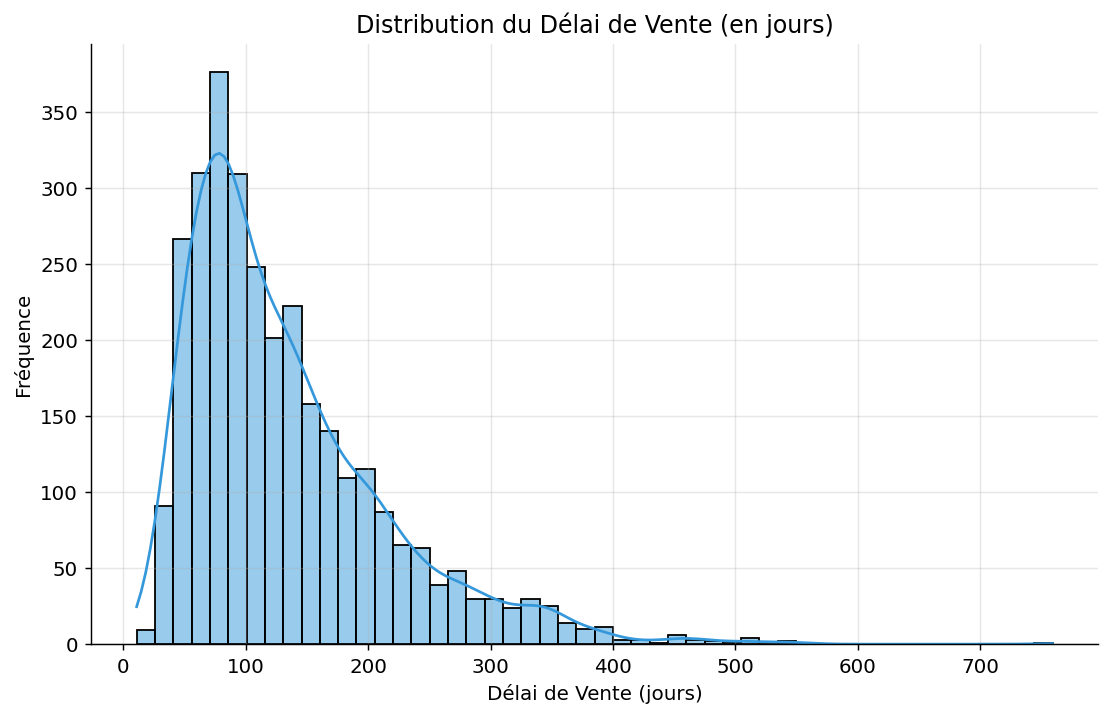

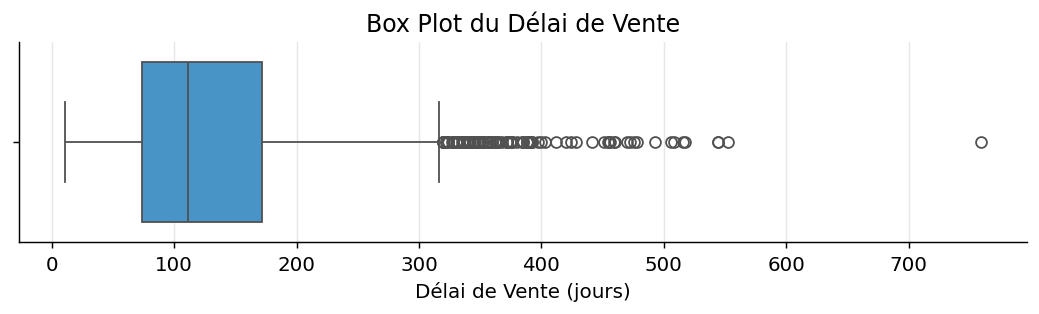

In [18]:
# --- Distribution de la variable cible : DELAI_VENTE ---

plt.figure(figsize=(10, 6))
sns.histplot(df['DELAI_VENTE'].dropna(), kde=True, bins=50, color=C_BLUE)
plt.title('Distribution du Délai de Vente (en jours)')
plt.xlabel('Délai de Vente (jours)')
plt.ylabel('Fréquence')
plt.show()

plt.figure(figsize=(10, 2))
sns.boxplot(x=df['DELAI_VENTE'].dropna(), color=C_BLUE)
plt.title('Box Plot du Délai de Vente')
plt.xlabel('Délai de Vente (jours)')
plt.show()


### 2.1. Impact des variables catégorielles sur le Délai de Vente


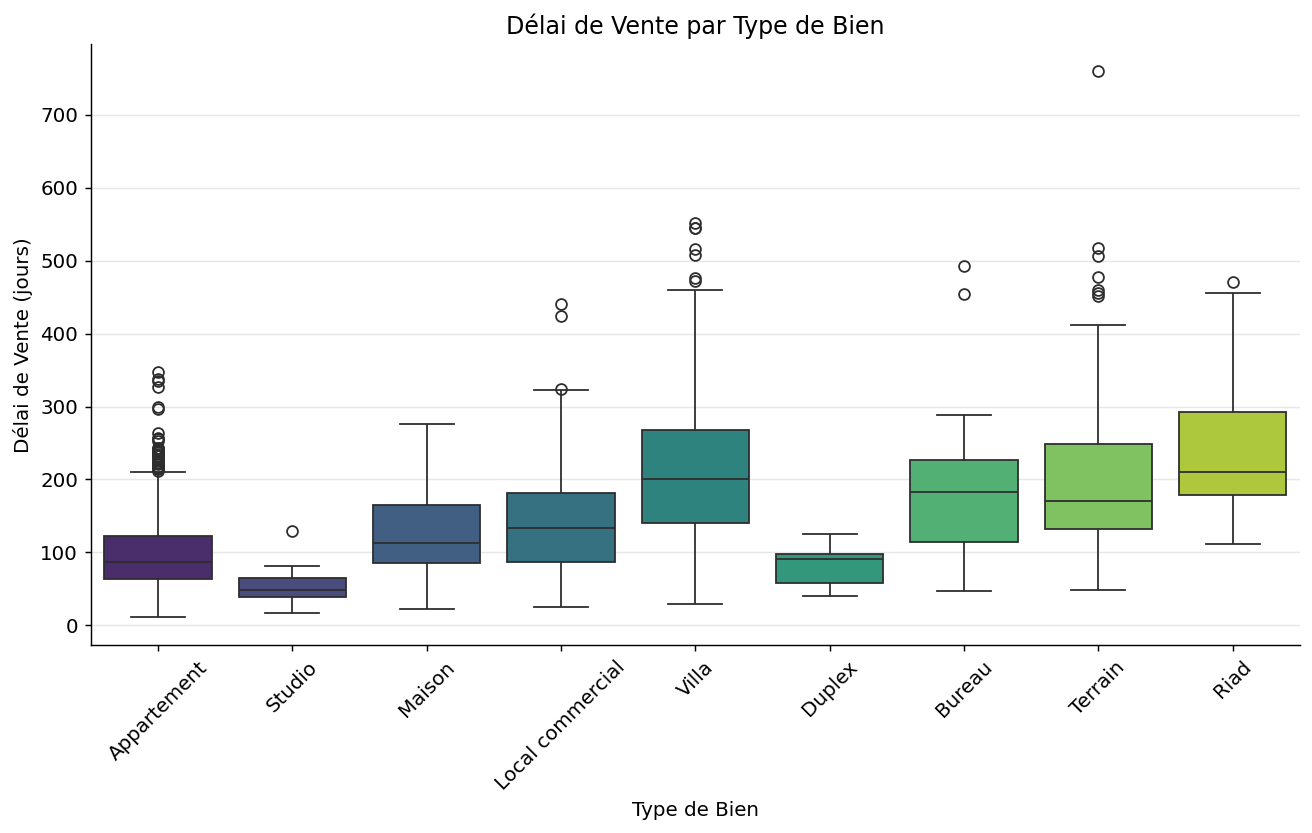

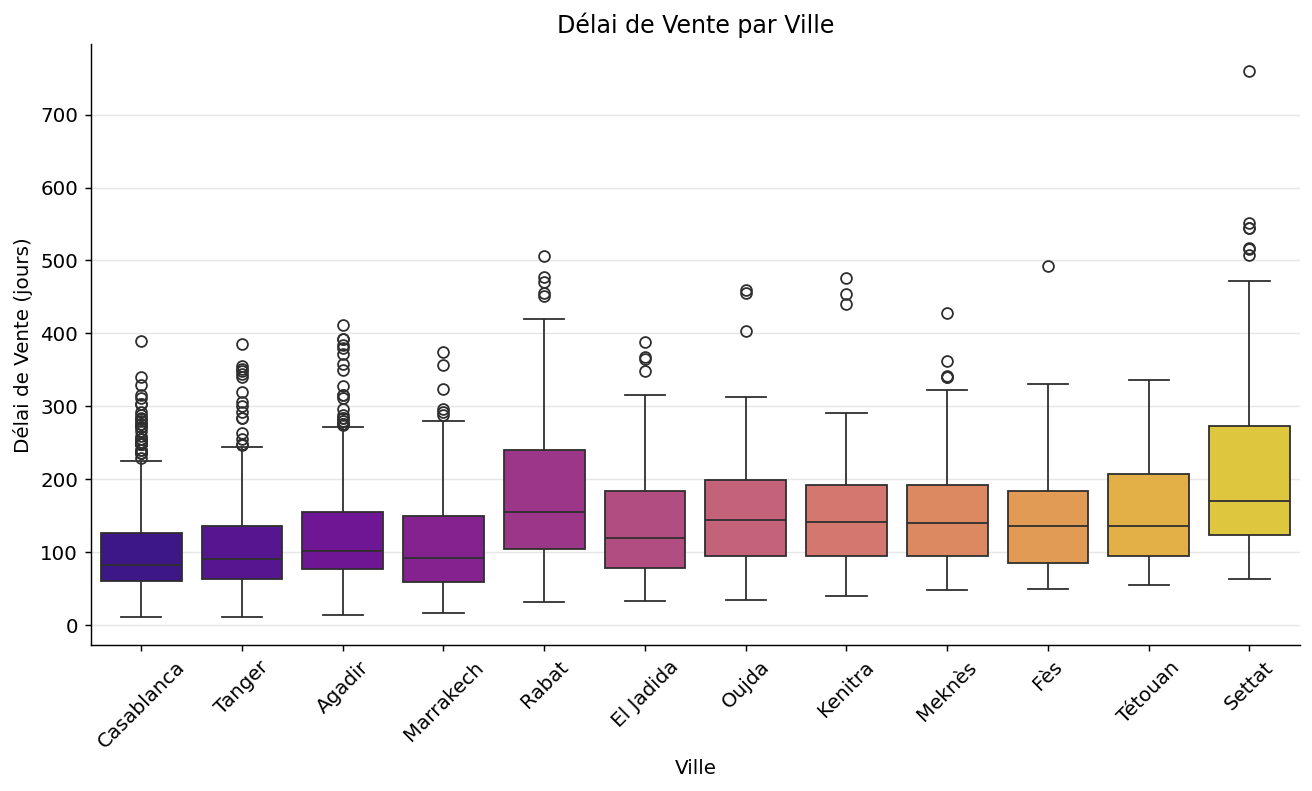

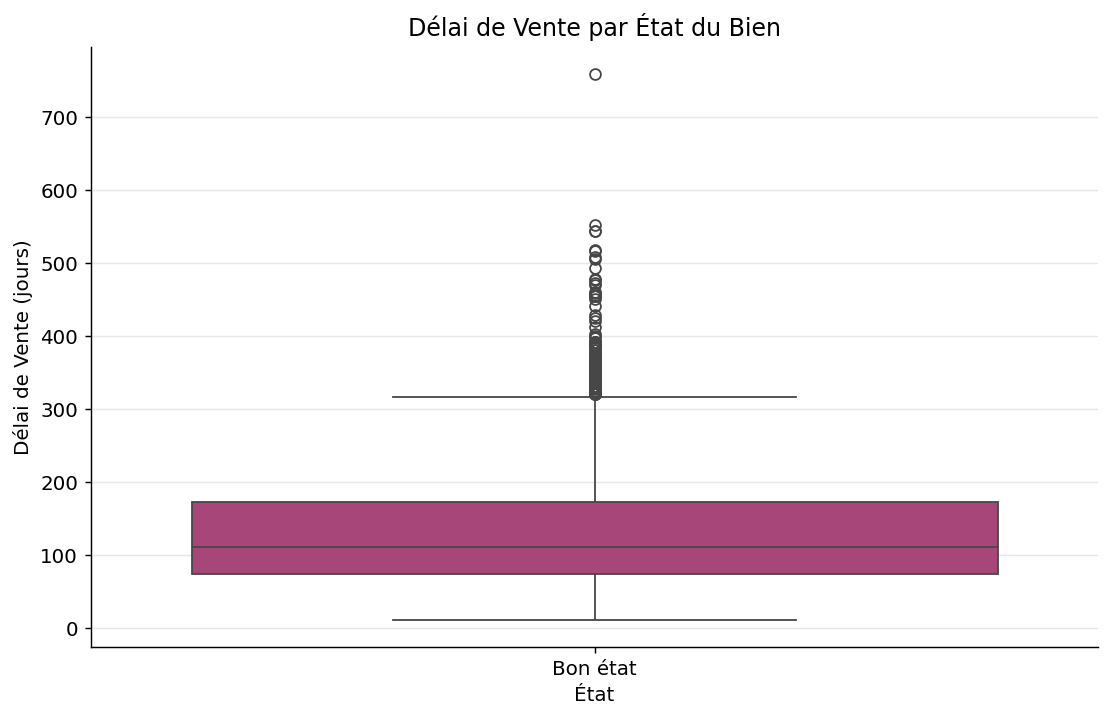

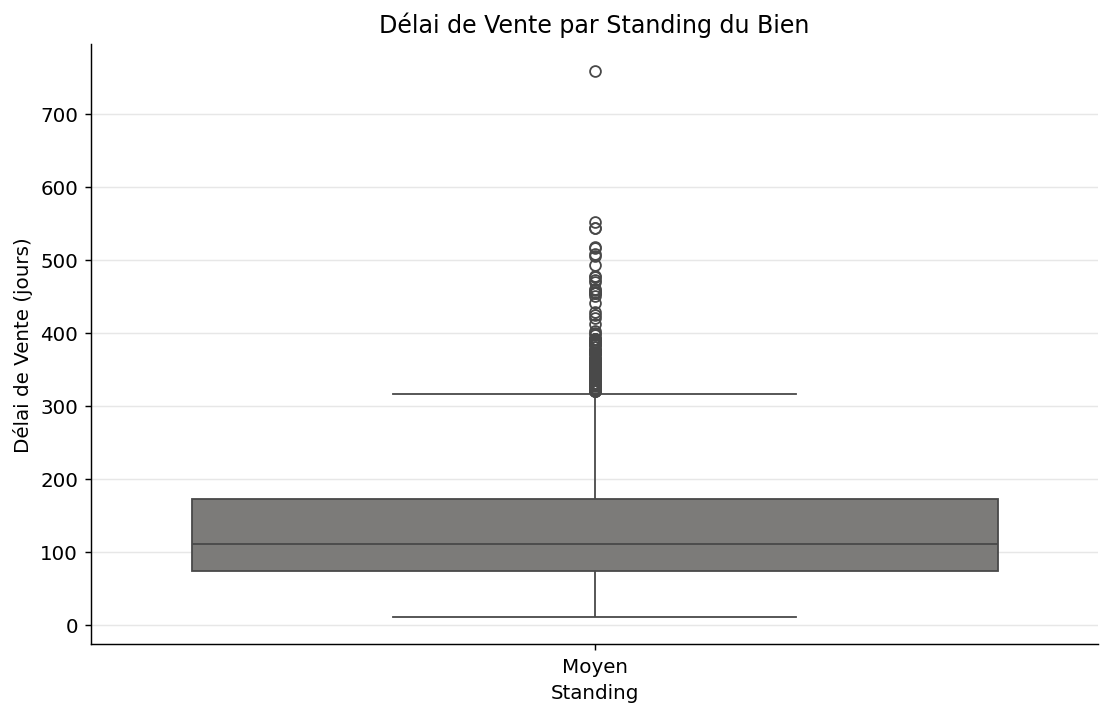

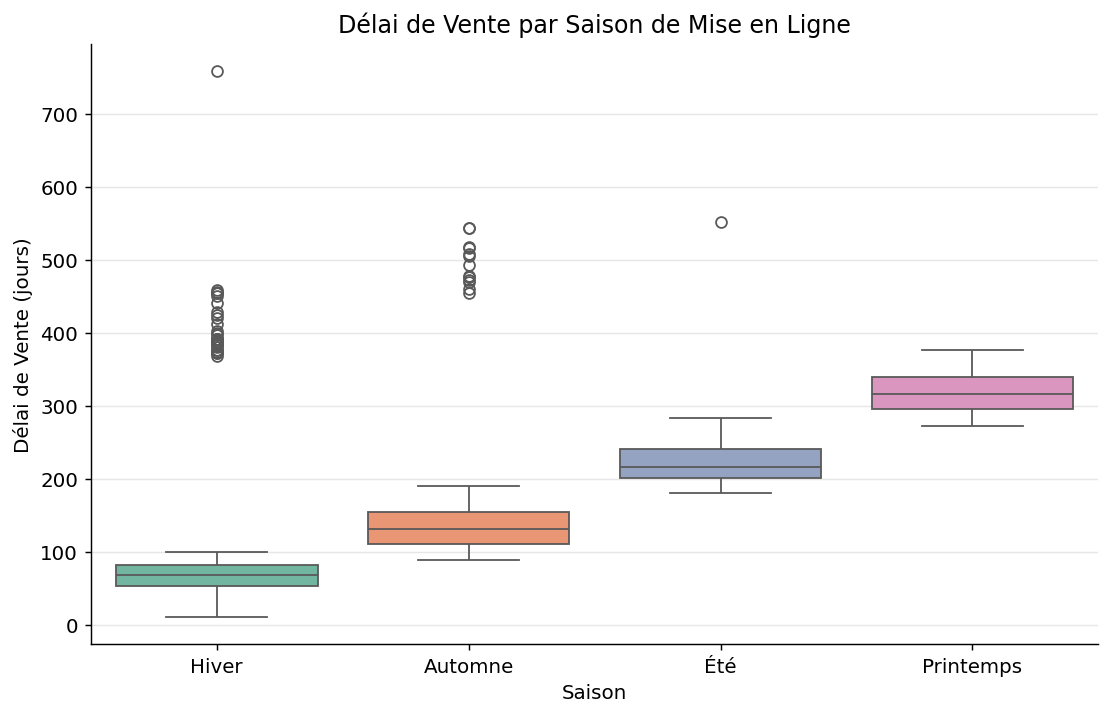

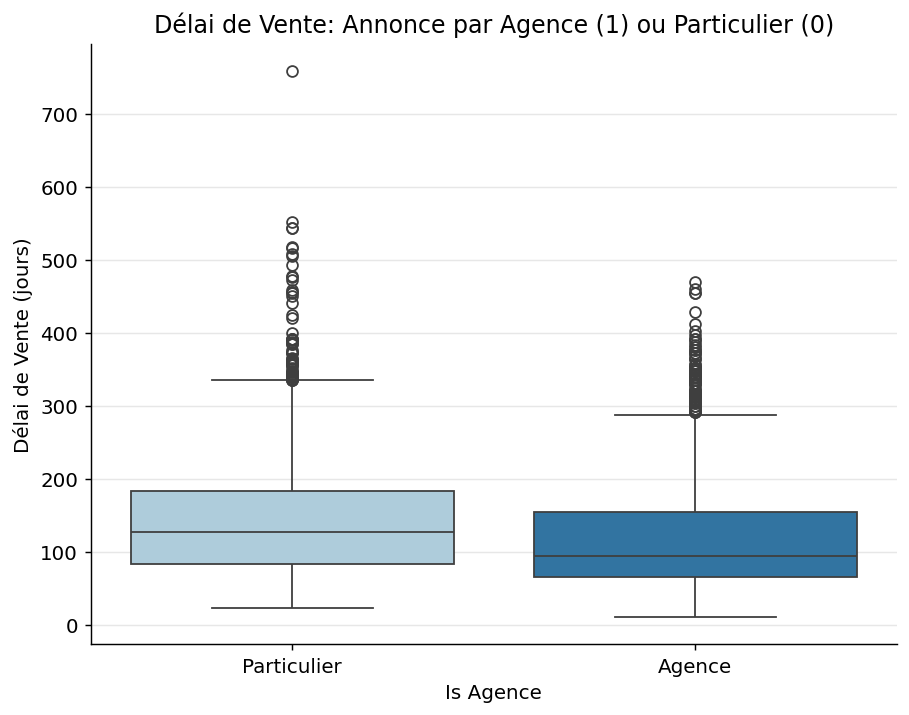

In [19]:
# Impact du Type de bien
plt.figure(figsize=(12, 6))
sns.boxplot(x='TYPE', y='DELAI_VENTE', data=df.sort_values('DELAI_VENTE'), palette='viridis')
plt.title('Délai de Vente par Type de Bien')
plt.xlabel('Type de Bien')
plt.ylabel('Délai de Vente (jours)')
plt.xticks(rotation=45)
plt.show()

# Impact de la Ville
plt.figure(figsize=(12, 6))
sns.boxplot(x='VILLE', y='DELAI_VENTE', data=df.sort_values('DELAI_VENTE'), palette='plasma')
plt.title('Délai de Vente par Ville')
plt.xlabel('Ville')
plt.ylabel('Délai de Vente (jours)')
plt.xticks(rotation=45)
plt.show()

# Impact de l'État du bien
plt.figure(figsize=(10, 6))
sns.boxplot(x='ETAT', y='DELAI_VENTE', data=df.sort_values('DELAI_VENTE'), palette='magma')
plt.title('Délai de Vente par État du Bien')
plt.xlabel('État')
plt.ylabel('Délai de Vente (jours)')
plt.show()

# Impact du Standing du bien
plt.figure(figsize=(10, 6))
sns.boxplot(x='STANDING', y='DELAI_VENTE', data=df.sort_values('DELAI_VENTE'), palette='cividis')
plt.title('Délai de Vente par Standing du Bien')
plt.xlabel('Standing')
plt.ylabel('Délai de Vente (jours)')
plt.show()

# Impact de la Saison de mise en ligne
plt.figure(figsize=(10, 6))
sns.boxplot(x='SAISON', y='DELAI_VENTE', data=df.sort_values('DELAI_VENTE'), palette='Set2')
plt.title('Délai de Vente par Saison de Mise en Ligne')
plt.xlabel('Saison')
plt.ylabel('Délai de Vente (jours)')
plt.show()

# Impact de l'Agence vs Particulier
plt.figure(figsize=(8, 6))
sns.boxplot(x='IS_AGENCE', y='DELAI_VENTE', data=df, palette='Paired')
plt.title('Délai de Vente: Annonce par Agence (1) ou Particulier (0)')
plt.xlabel('Is Agence')
plt.ylabel('Délai de Vente (jours)')
plt.xticks([0, 1], ['Particulier', 'Agence'])
plt.show()


### 2.2. Impact des variables numériques sur le Délai de Vente


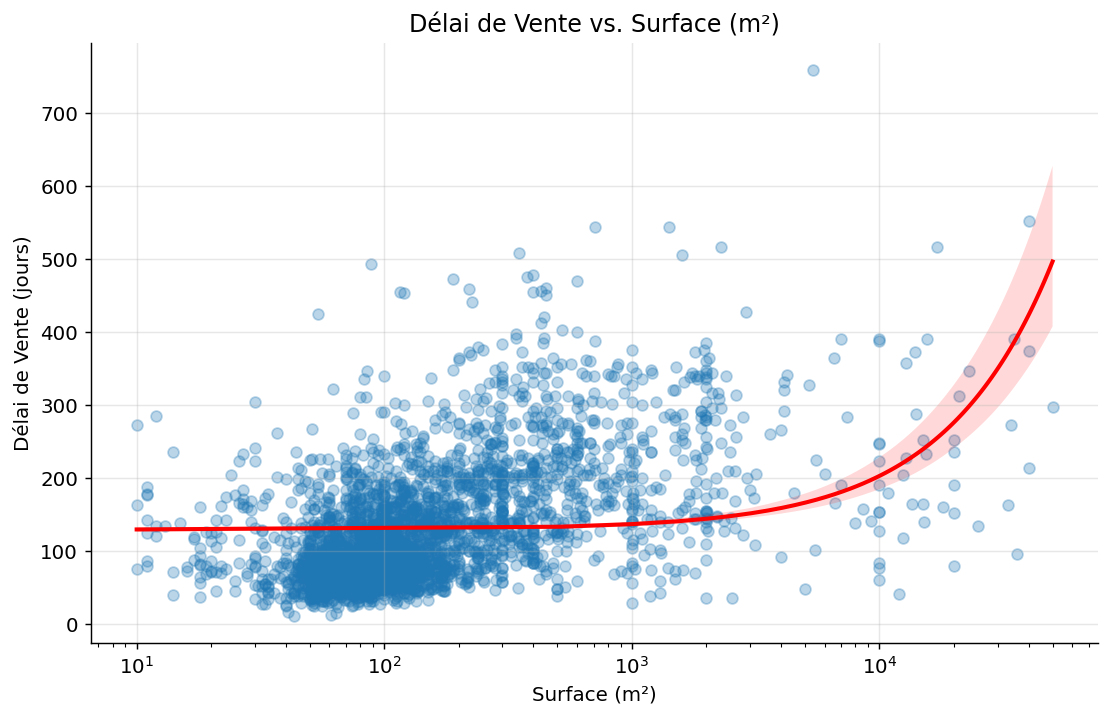

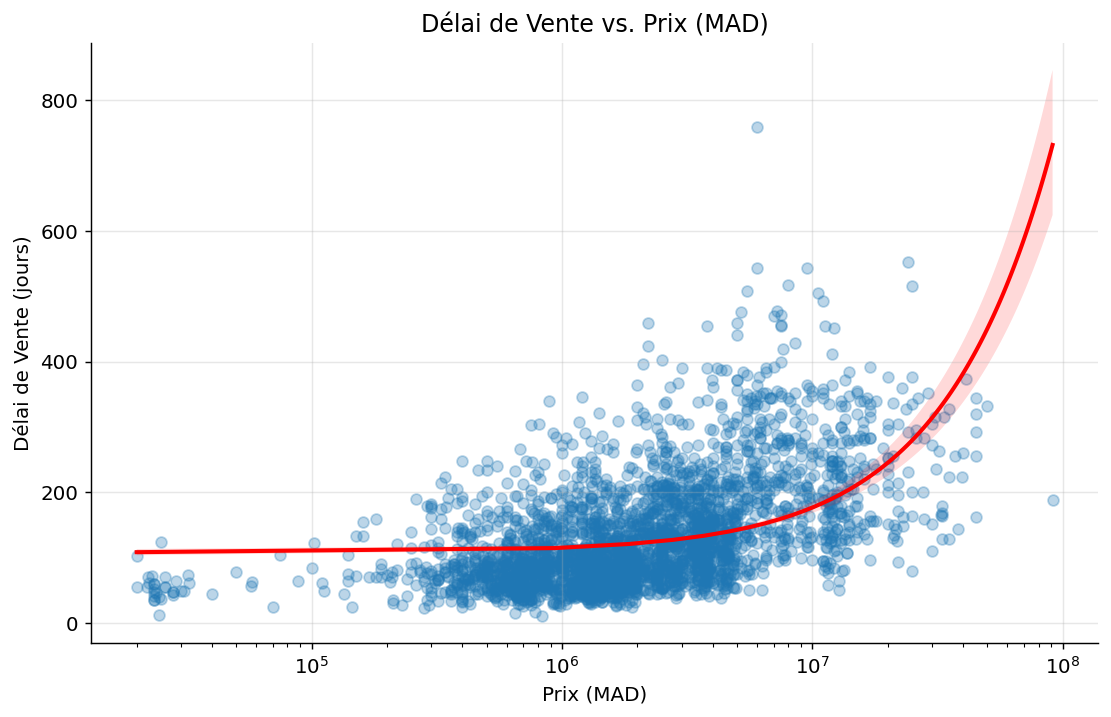

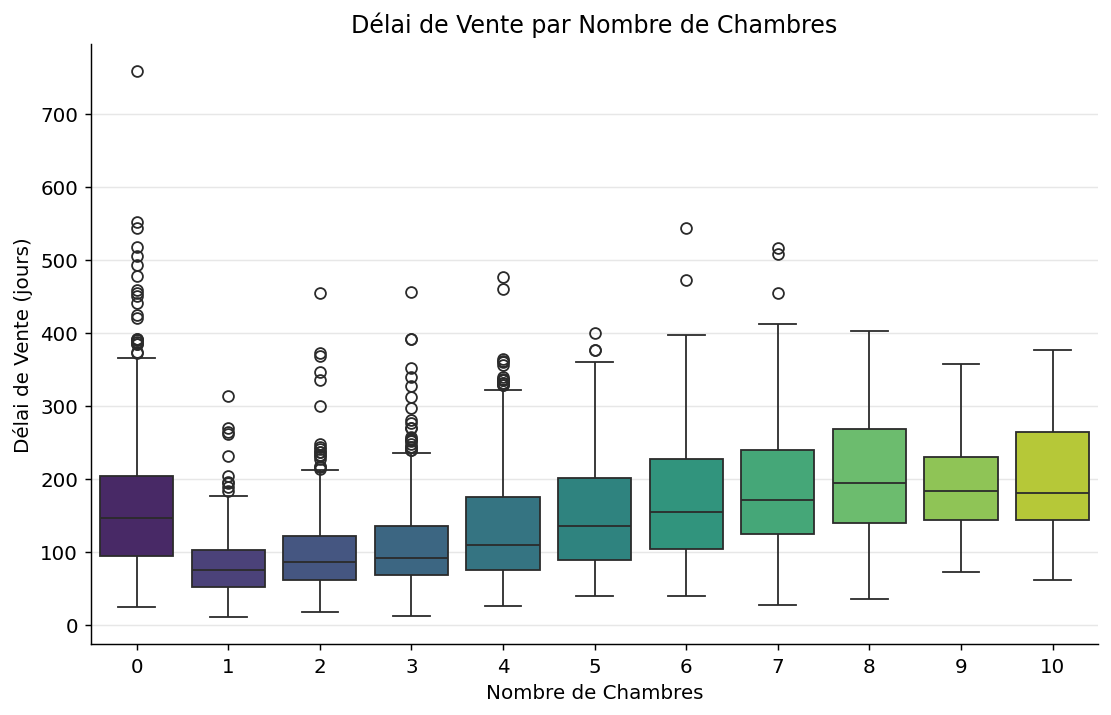

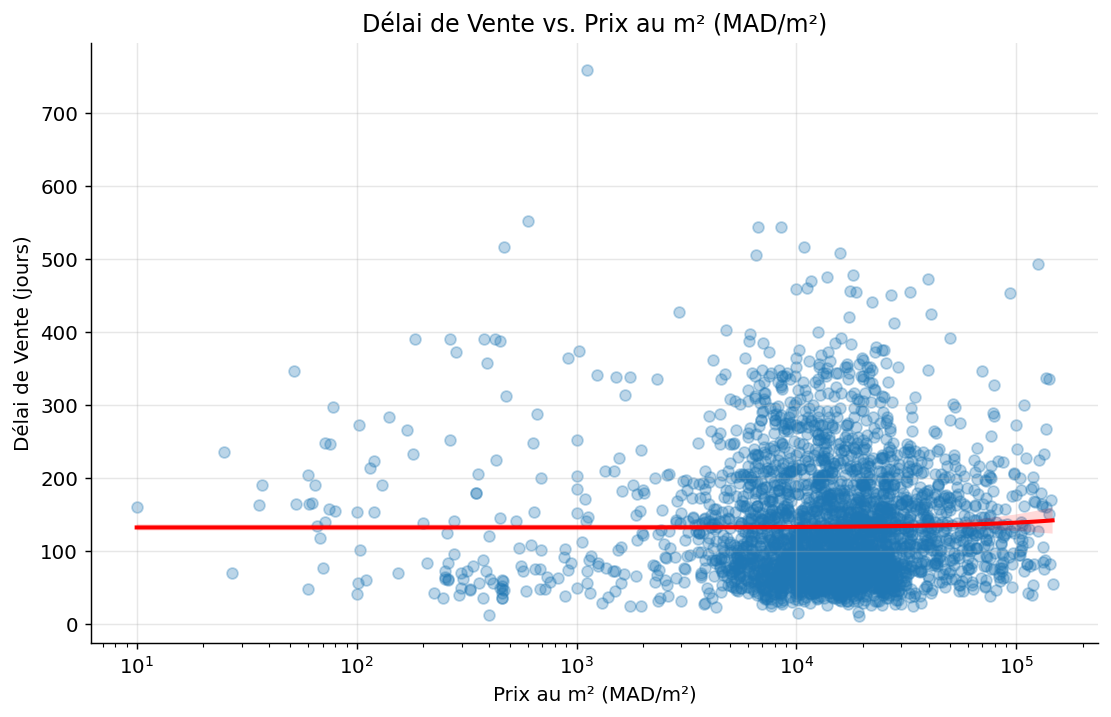

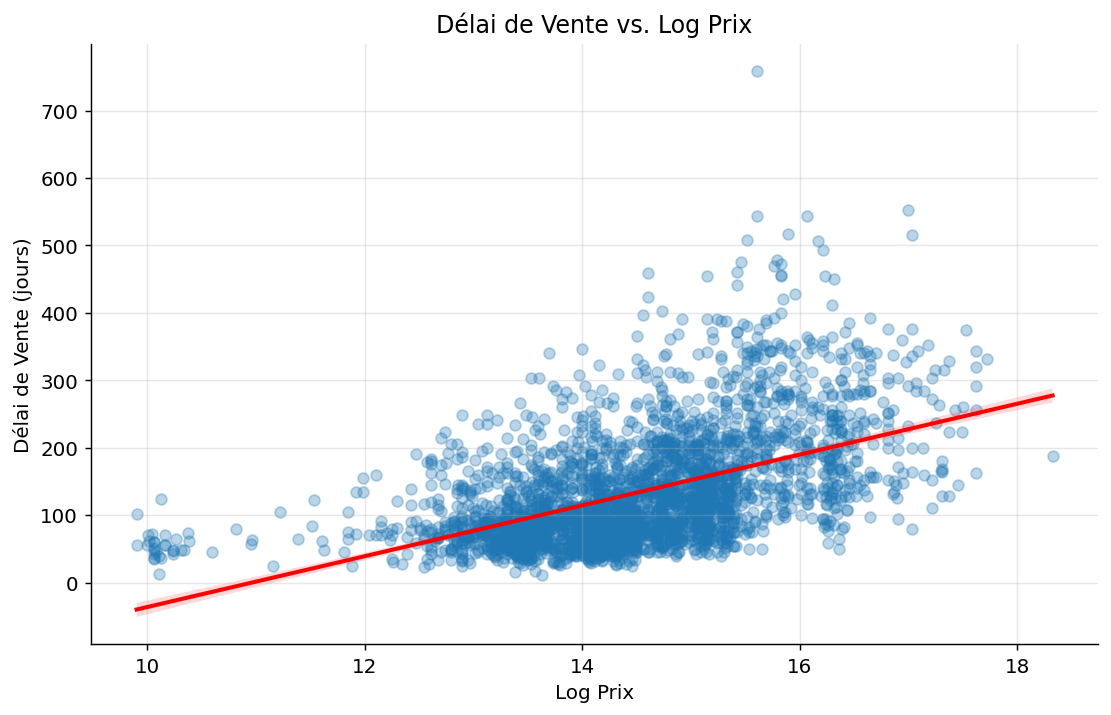

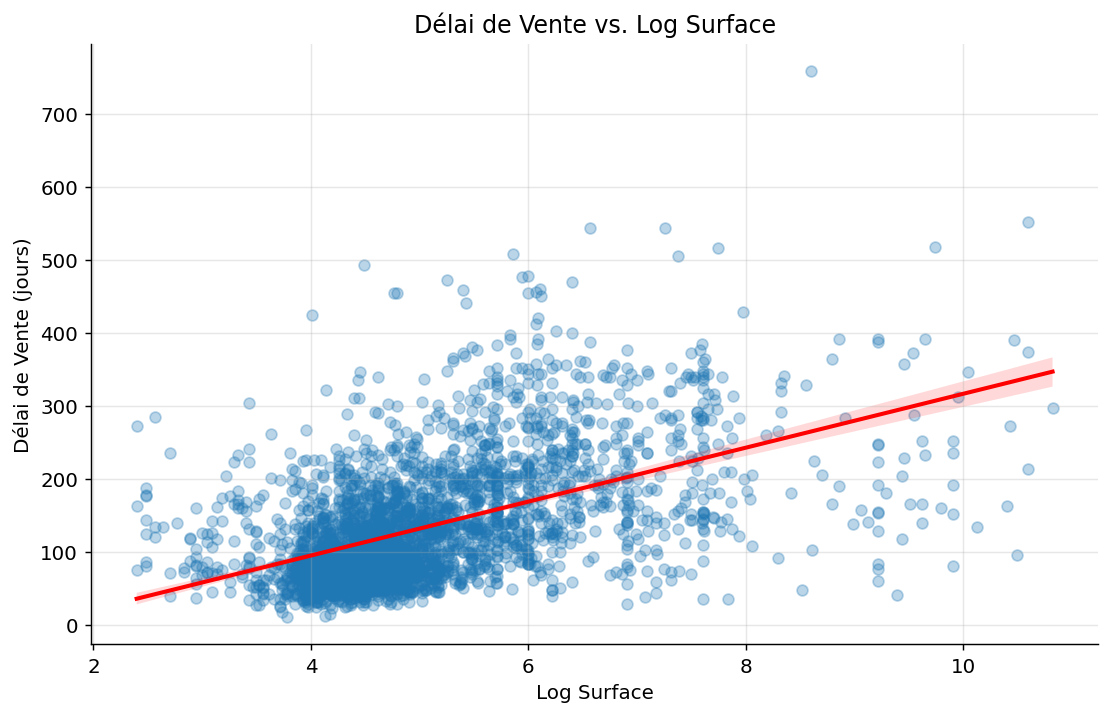

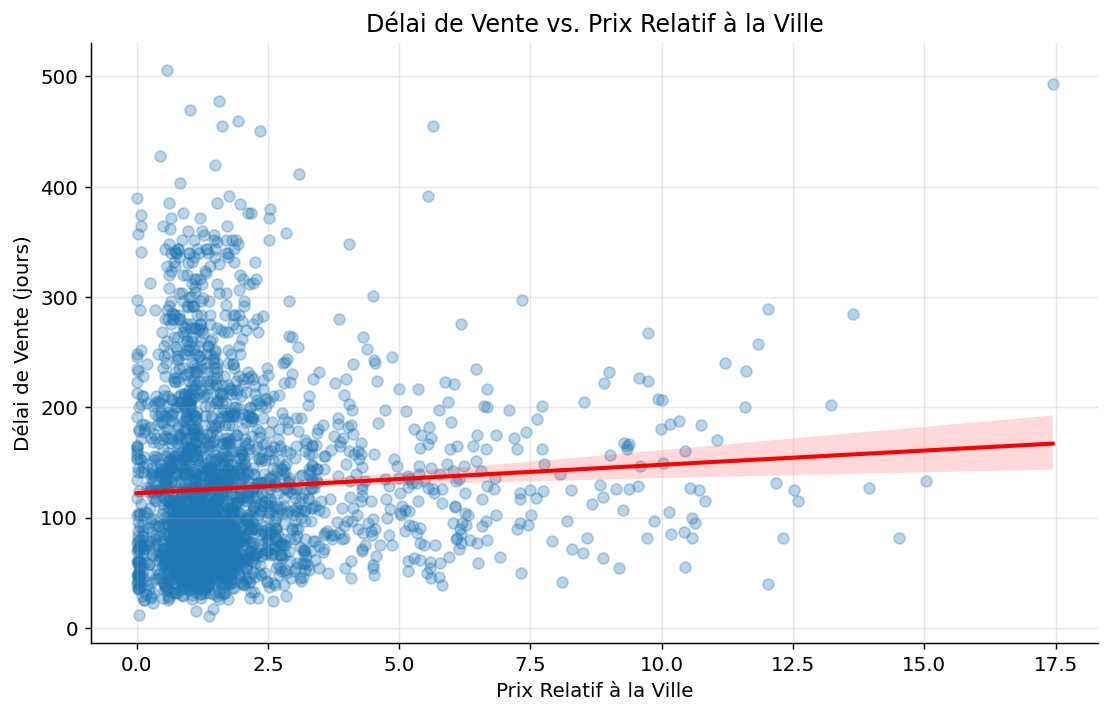

In [20]:
# Relation entre Surface et Délai de Vente
plt.figure(figsize=(10, 6))
sns.regplot(x='SURF_M2', y='DELAI_VENTE', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Délai de Vente vs. Surface (m²)')
plt.xlabel('Surface (m²)')
plt.ylabel('Délai de Vente (jours)')
plt.xscale('log')
plt.show()

# Relation entre Prix et Délai de Vente
plt.figure(figsize=(10, 6))
sns.regplot(x='PRIX_MAD', y='DELAI_VENTE', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Délai de Vente vs. Prix (MAD)')
plt.xlabel('Prix (MAD)')
plt.ylabel('Délai de Vente (jours)')
plt.xscale('log')
plt.show()

# Relation entre Chambres et Délai de Vente
plt.figure(figsize=(10, 6))
sns.boxplot(x='CHAMBRES', y='DELAI_VENTE', data=df, palette='viridis')
plt.title('Délai de Vente par Nombre de Chambres')
plt.xlabel('Nombre de Chambres')
plt.ylabel('Délai de Vente (jours)')
plt.show()

# Relation entre MAD/m² et Délai de Vente
plt.figure(figsize=(10, 6))
sns.regplot(x='MAD_M2', y='DELAI_VENTE', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Délai de Vente vs. Prix au m² (MAD/m²)')
plt.xlabel('Prix au m² (MAD/m²)')
plt.ylabel('Délai de Vente (jours)')
plt.xscale('log')
plt.show()

# Relation entre LOG_PRIX et Délai de Vente
plt.figure(figsize=(10, 6))
sns.regplot(x='LOG_PRIX', y='DELAI_VENTE', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Délai de Vente vs. Log Prix')
plt.xlabel('Log Prix')
plt.ylabel('Délai de Vente (jours)')
plt.show()

# Relation entre LOG_SURFACE et Délai de Vente
plt.figure(figsize=(10, 6))
sns.regplot(x='LOG_SURFACE', y='DELAI_VENTE', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Délai de Vente vs. Log Surface')
plt.xlabel('Log Surface')
plt.ylabel('Délai de Vente (jours)')
plt.show()

# Relation entre PRIX_REL_VILLE et Délai de Vente
plt.figure(figsize=(10, 6))
sns.regplot(x='PRIX_REL_VILLE', y='DELAI_VENTE', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Délai de Vente vs. Prix Relatif à la Ville')
plt.xlabel('Prix Relatif à la Ville')
plt.ylabel('Délai de Vente (jours)')
plt.show()


## 3. Matrice de Corrélation

Visualisation des corrélations entre les variables numériques et la variable cible `DELAI_VENTE`.


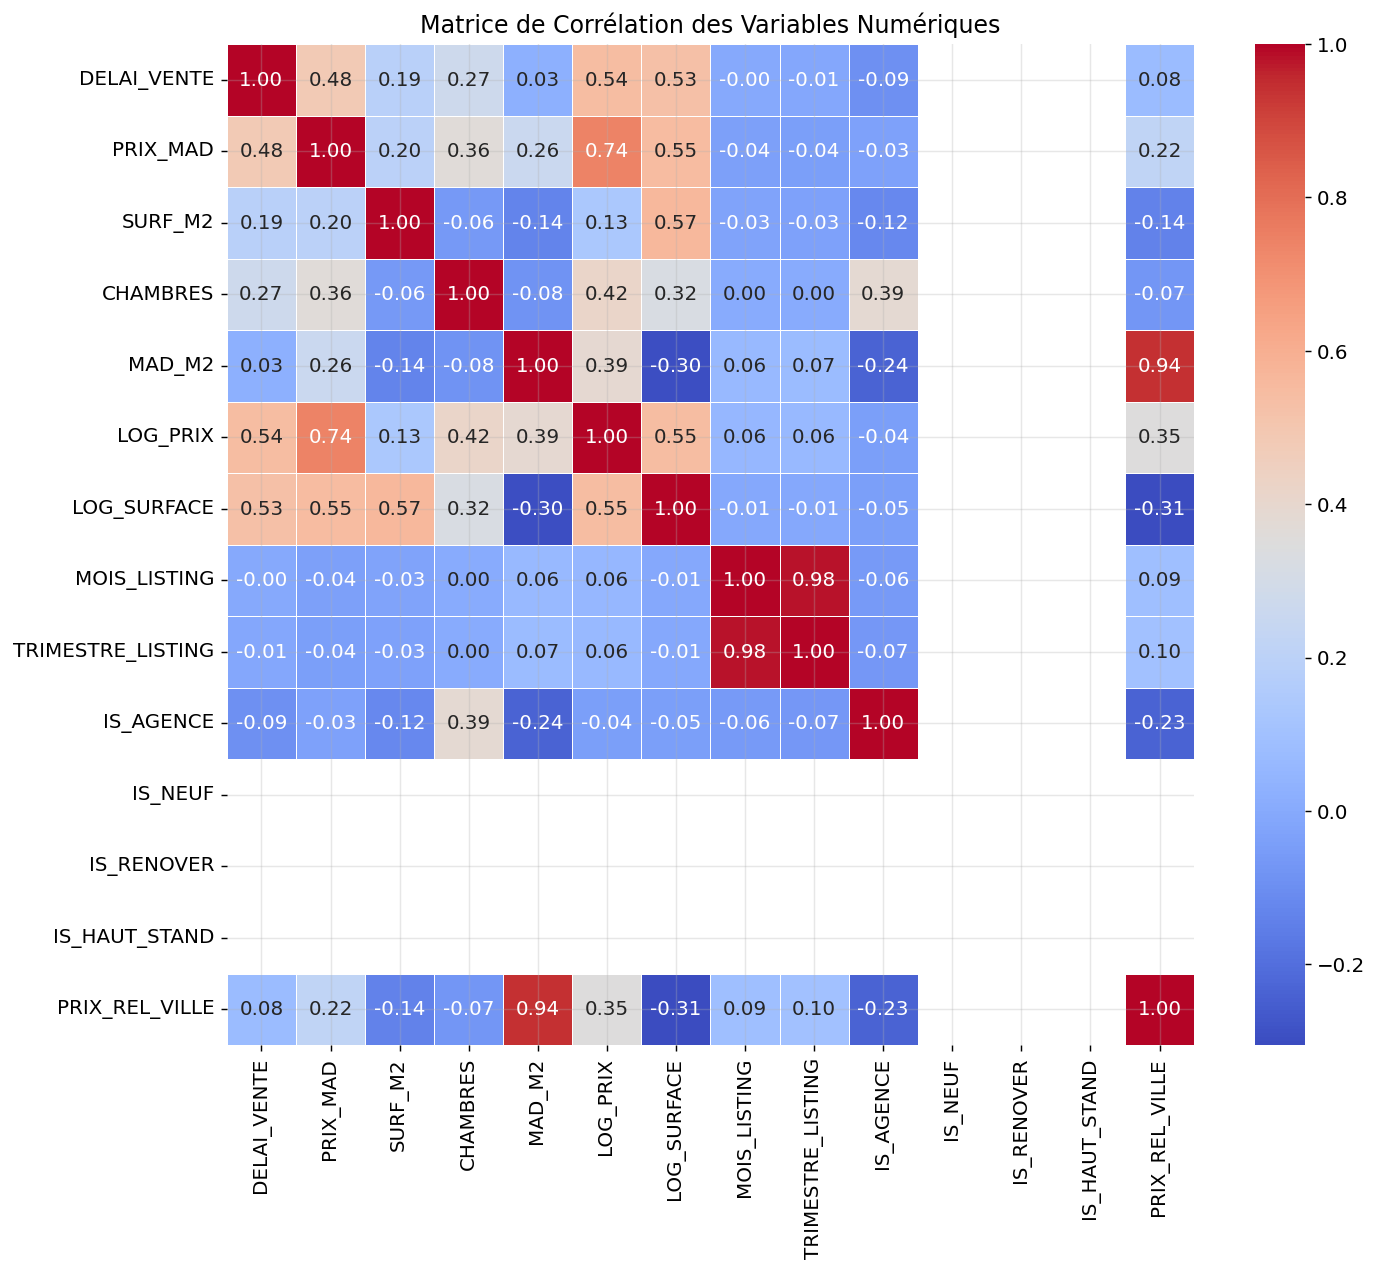


Corrélations avec DELAI_VENTE:
DELAI_VENTE          1.000000
LOG_PRIX             0.543416
LOG_SURFACE          0.527854
PRIX_MAD             0.480608
CHAMBRES             0.273048
SURF_M2              0.188928
PRIX_REL_VILLE       0.075166
MAD_M2               0.025157
MOIS_LISTING        -0.002715
TRIMESTRE_LISTING   -0.012373
IS_AGENCE           -0.093124
IS_NEUF                   NaN
IS_RENOVER                NaN
IS_HAUT_STAND             NaN


In [21]:
num_cols_corr = ['DELAI_VENTE', 'PRIX_MAD', 'SURF_M2', 'CHAMBRES', 'MAD_M2', 'LOG_PRIX', 'LOG_SURFACE', 'MOIS_LISTING', 'TRIMESTRE_LISTING', 'IS_AGENCE', 'IS_NEUF', 'IS_RENOVER', 'IS_HAUT_STAND', 'PRIX_REL_VILLE']
df_corr = df[num_cols_corr].dropna()

plt.figure(figsize=(12, 10))
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de Corrélation des Variables Numériques')
plt.show()

# Corrélations avec la variable cible
corr_target = corr_matrix['DELAI_VENTE'].sort_values(ascending=False)
print("\nCorrélations avec DELAI_VENTE:")
print(corr_target.to_string())


## 5. Comparaison des Modèles

Cette section compare les performances de plusieurs modèles de régression pour prédire le `DELAI_VENTE`. Pour chaque modèle, nous utiliserons un pipeline incluant le prétraitement défini précédemment, ainsi qu'une validation croisée pour une évaluation robuste.

In [25]:
# Dictionnaire des modèles à tester
MODELS = {
    'Régression Linéaire': LinearRegression(),
    'Ridge': Ridge(alpha=10.0),
    'Lasso': Lasso(max_iter=10000),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42),
    'SVR': SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    'KNeighbors': KNeighborsRegressor(n_neighbors=5)
}

results = []
trained_pipes = {}

print("🚀 Démarrage de l'entraînement et de l'évaluation des modèles...")

for name, model in MODELS.items():
    print(f"\n--- Modèle : {name} ---")
    # Création du pipeline complet avec prétraitement et modèle
    pipeline = Pipeline(steps=[('prep', preprocessor), ('model', model)])

    # Entraînement du modèle
    pipeline.fit(X_train, y_train)
    trained_pipes[name] = pipeline # Sauvegarde du pipeline entraîné

    # Prédiction sur l'ensemble de test
    y_pred = pipeline.predict(X_test)

    # Évaluation des métriques
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Validation croisée
    cv_scores = cross_val_score(pipeline, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2')
    cv_r2 = np.mean(cv_scores)

    # Verdict basé sur le R² en validation croisée
    verdict = "✅ Excellent" if cv_r2 > 0.8 else ("👍 Bon" if cv_r2 > 0.6 else "🤔 Moyen")

    print(f"   R² (Test): {r2:.4f}")
    print(f"   RMSE (Test): {rmse:.1f} jours")
    print(f"   MAE (Test): {mae:.1f} jours")
    print(f"   R² (Cross-Val): {cv_r2:.4f} {verdict}")

    results.append({
        'Modèle': name,
        'R²': round(r2, 4),
        'RMSE (j)': round(rmse, 1),
        'MAE (j)': round(mae, 1),
        'CV R²': round(cv_r2, 4),
        'Verdict': verdict
    })

df_res = pd.DataFrame(results).sort_values(by='CV R²', ascending=False)
print("\n--- Résumé des performances des modèles ---")
print(df_res.to_string())


🚀 Démarrage de l'entraînement et de l'évaluation des modèles...

--- Modèle : Régression Linéaire ---
   R² (Test): 0.7760
   RMSE (Test): 37.8 jours
   MAE (Test): 24.6 jours
   R² (Cross-Val): 0.7298 👍 Bon

--- Modèle : Ridge ---
   R² (Test): 0.8187
   RMSE (Test): 34.0 jours
   MAE (Test): 22.9 jours
   R² (Cross-Val): 0.7641 👍 Bon

--- Modèle : Lasso ---
   R² (Test): 0.7937
   RMSE (Test): 36.2 jours
   MAE (Test): 24.5 jours
   R² (Cross-Val): 0.7255 👍 Bon

--- Modèle : Decision Tree ---
   R² (Test): 0.8172
   RMSE (Test): 34.1 jours
   MAE (Test): 13.0 jours
   R² (Cross-Val): 0.8101 ✅ Excellent

--- Modèle : Random Forest ---
   R² (Test): 0.8638
   RMSE (Test): 29.4 jours
   MAE (Test): 10.7 jours
   R² (Cross-Val): 0.8342 ✅ Excellent

--- Modèle : Gradient Boosting ---
   R² (Test): 0.8786
   RMSE (Test): 27.8 jours
   MAE (Test): 12.5 jours
   R² (Cross-Val): 0.8597 ✅ Excellent

--- Modèle : Extra Trees ---
   R² (Test): 0.8693
   RMSE (Test): 28.9 jours
   MAE (Test): 10.

## 5. Comparaison des Modèles

Cette section compare les performances de plusieurs modèles de régression pour prédire le `DELAI_VENTE`. Pour chaque modèle, nous utiliserons un pipeline incluant le prétraitement défini précédemment, ainsi qu'une validation croisée pour une évaluation robuste.

In [26]:
# Dictionnaire des modèles à tester
MODELS = {
    'Régression Linéaire': LinearRegression(),
    'Ridge': Ridge(alpha=10.0),
    'Lasso': Lasso(max_iter=10000),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42),
    'SVR': SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    'KNeighbors': KNeighborsRegressor(n_neighbors=5)
}

results = []
trained_pipes = {}

print("🚀 Démarrage de l'entraînement et de l'évaluation des modèles...")

for name, model in MODELS.items():
    print(f"\n--- Modèle : {name} ---")
    # Création du pipeline complet avec prétraitement et modèle
    pipeline = Pipeline(steps=[('prep', preprocessor), ('model', model)])

    # Entraînement du modèle
    pipeline.fit(X_train, y_train)
    trained_pipes[name] = pipeline # Sauvegarde du pipeline entraîné

    # Prédiction sur l'ensemble de test
    y_pred = pipeline.predict(X_test)

    # Évaluation des métriques
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Validation croisée
    cv_scores = cross_val_score(pipeline, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2')
    cv_r2 = np.mean(cv_scores)

    # Verdict basé sur le R² en validation croisée
    verdict = "✅ Excellent" if cv_r2 > 0.8 else ("👍 Bon" if cv_r2 > 0.6 else "🤔 Moyen")

    print(f"   R² (Test): {r2:.4f}")
    print(f"   RMSE (Test): {rmse:.1f} jours")
    print(f"   MAE (Test): {mae:.1f} jours")
    print(f"   R² (Cross-Val): {cv_r2:.4f} {verdict}")

    results.append({
        'Modèle': name,
        'R²': round(r2, 4),
        'RMSE (j)': round(rmse, 1),
        'MAE (j)': round(mae, 1),
        'CV R²': round(cv_r2, 4),
        'Verdict': verdict
    })

df_res = pd.DataFrame(results).sort_values(by='CV R²', ascending=False)
print("\n--- Résumé des performances des modèles ---")
print(df_res.to_string())


🚀 Démarrage de l'entraînement et de l'évaluation des modèles...

--- Modèle : Régression Linéaire ---
   R² (Test): 0.7760
   RMSE (Test): 37.8 jours
   MAE (Test): 24.6 jours
   R² (Cross-Val): 0.7298 👍 Bon

--- Modèle : Ridge ---
   R² (Test): 0.8187
   RMSE (Test): 34.0 jours
   MAE (Test): 22.9 jours
   R² (Cross-Val): 0.7641 👍 Bon

--- Modèle : Lasso ---
   R² (Test): 0.7937
   RMSE (Test): 36.2 jours
   MAE (Test): 24.5 jours
   R² (Cross-Val): 0.7255 👍 Bon

--- Modèle : Decision Tree ---
   R² (Test): 0.8172
   RMSE (Test): 34.1 jours
   MAE (Test): 13.0 jours
   R² (Cross-Val): 0.8101 ✅ Excellent

--- Modèle : Random Forest ---
   R² (Test): 0.8638
   RMSE (Test): 29.4 jours
   MAE (Test): 10.7 jours
   R² (Cross-Val): 0.8342 ✅ Excellent

--- Modèle : Gradient Boosting ---
   R² (Test): 0.8786
   RMSE (Test): 27.8 jours
   MAE (Test): 12.5 jours
   R² (Cross-Val): 0.8597 ✅ Excellent

--- Modèle : Extra Trees ---
   R² (Test): 0.8693
   RMSE (Test): 28.9 jours
   MAE (Test): 10.

## 6. Feature Importance

Cette section vise à identifier les caractéristiques (features) les plus importantes pour la prédiction du `DELAI_VENTE` en utilisant le meilleur modèle trouvé.

--- Importance des caractéristiques (Top 15) ---
                Feature  Importance
1137       SAISON_Hiver    0.297034
6          MOIS_LISTING    0.272347
4              LOG_PRIX    0.067389
14     TYPE_Appartement    0.065004
2              PRIX_MAD    0.036244
32         VILLE_Settat    0.032757
7     TRIMESTRE_LISTING    0.030840
1136     SAISON_Automne    0.030629
1138   SAISON_Printemps    0.029812
5           LOG_SURFACE    0.027097
0               SURF_M2    0.014514
1139         SAISON_Été    0.013025
13       PRIX_REL_VILLE    0.008035
21         TYPE_Terrain    0.007643
19            TYPE_Riad    0.007547


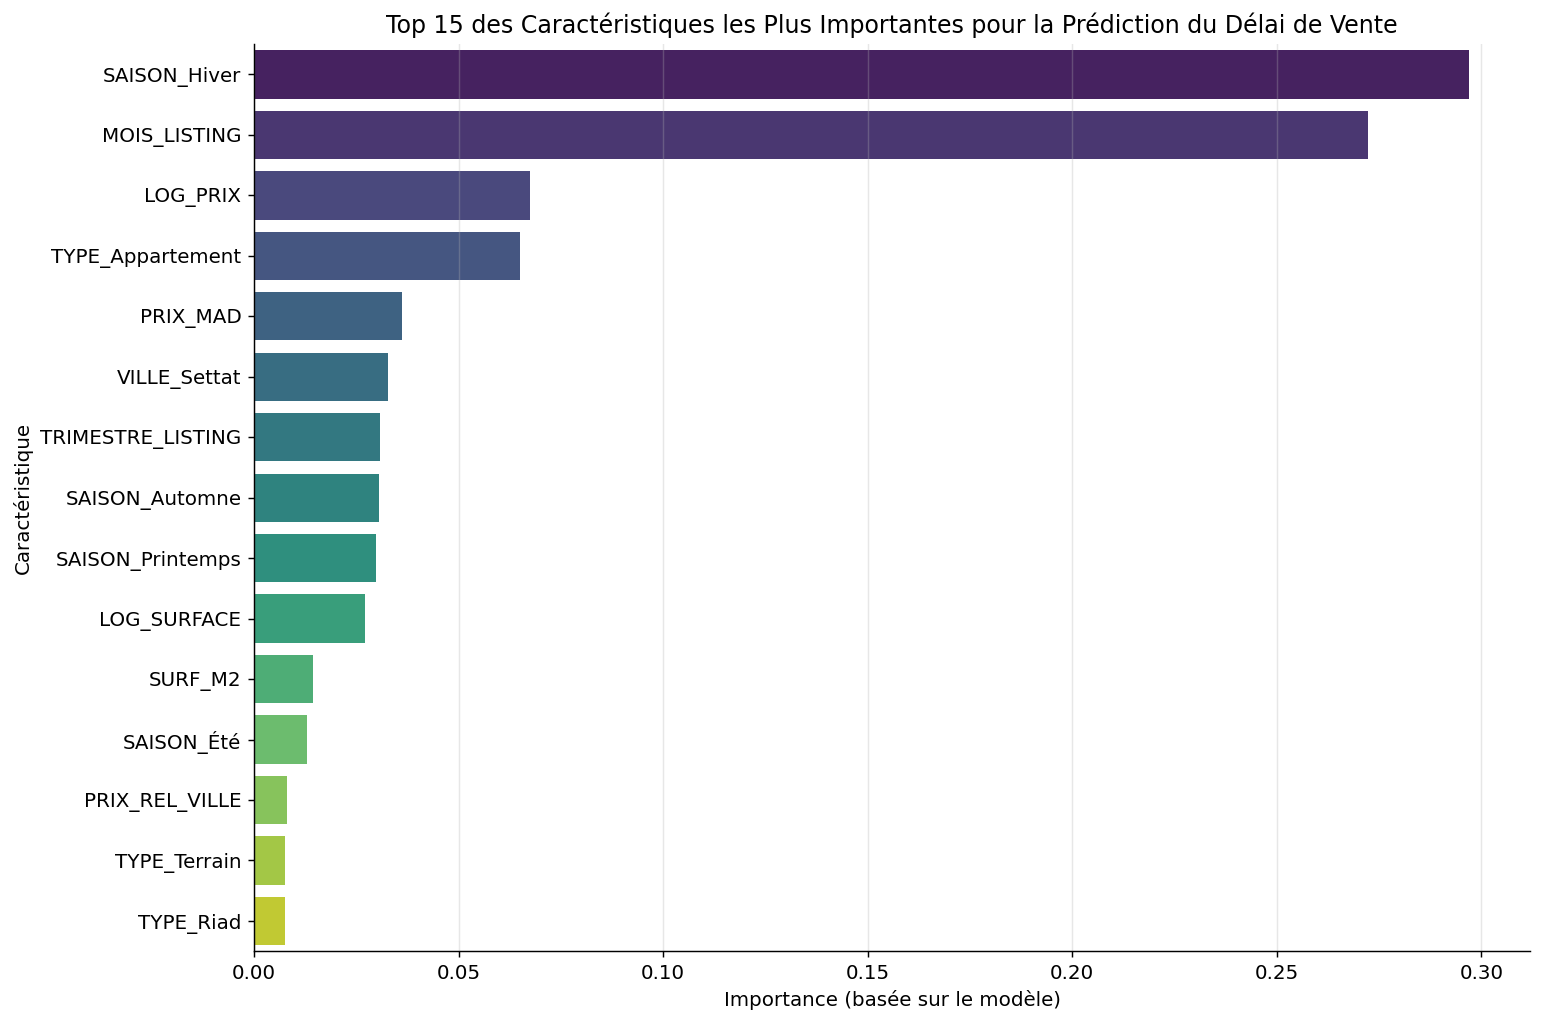

In [27]:
# Récupérer le meilleur modèle (Gradient Boosting d'après nos résultats)
best_model_name = df_res.iloc[0]['Modèle']
best_pipeline = trained_pipes[best_model_name]

# Accéder au modèle entraîné (dernier pas du pipeline)
best_model = best_pipeline.named_steps['model']

# Récupérer les noms des features après le prétraitement OneHotEncoder
ohe_feature_names = best_pipeline.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(CAT_FEATURES)
all_feature_names = list(NUM_FEATURES) + list(ohe_feature_names)

# Calculer l'importance des caractéristiques (spécifique aux modèles basés sur les arbres)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False)

    print("--- Importance des caractéristiques (Top 15) ---")
    print(feat_df.head(15).to_string())

    # Visualisation des 15 caractéristiques les plus importantes
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_df.head(15), palette='viridis')
    plt.title('Top 15 des Caractéristiques les Plus Importantes pour la Prédiction du Délai de Vente')
    plt.xlabel('Importance (basée sur le modèle)')
    plt.ylabel('Caractéristique')
    plt.tight_layout()
    plt.show()

else:
    print(f"Le modèle {best_model_name} n'a pas d'attribut feature_importances_.")
    print("Considérer l'utilisation de `permutation_importance` pour une approche agnostique au modèle.")
    # Calcul de permutation importance pour une approche agnostique au modèle
    # r = permutation_importance(best_pipeline, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
    # feat_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': r.importances_mean})
    # feat_df = feat_df.sort_values(by='Importance', ascending=False)
    # print(feat_df.head(15).to_string())


## 7. Visualisations des Résultats ML

Cette section visualise les performances du meilleur modèle de Machine Learning.


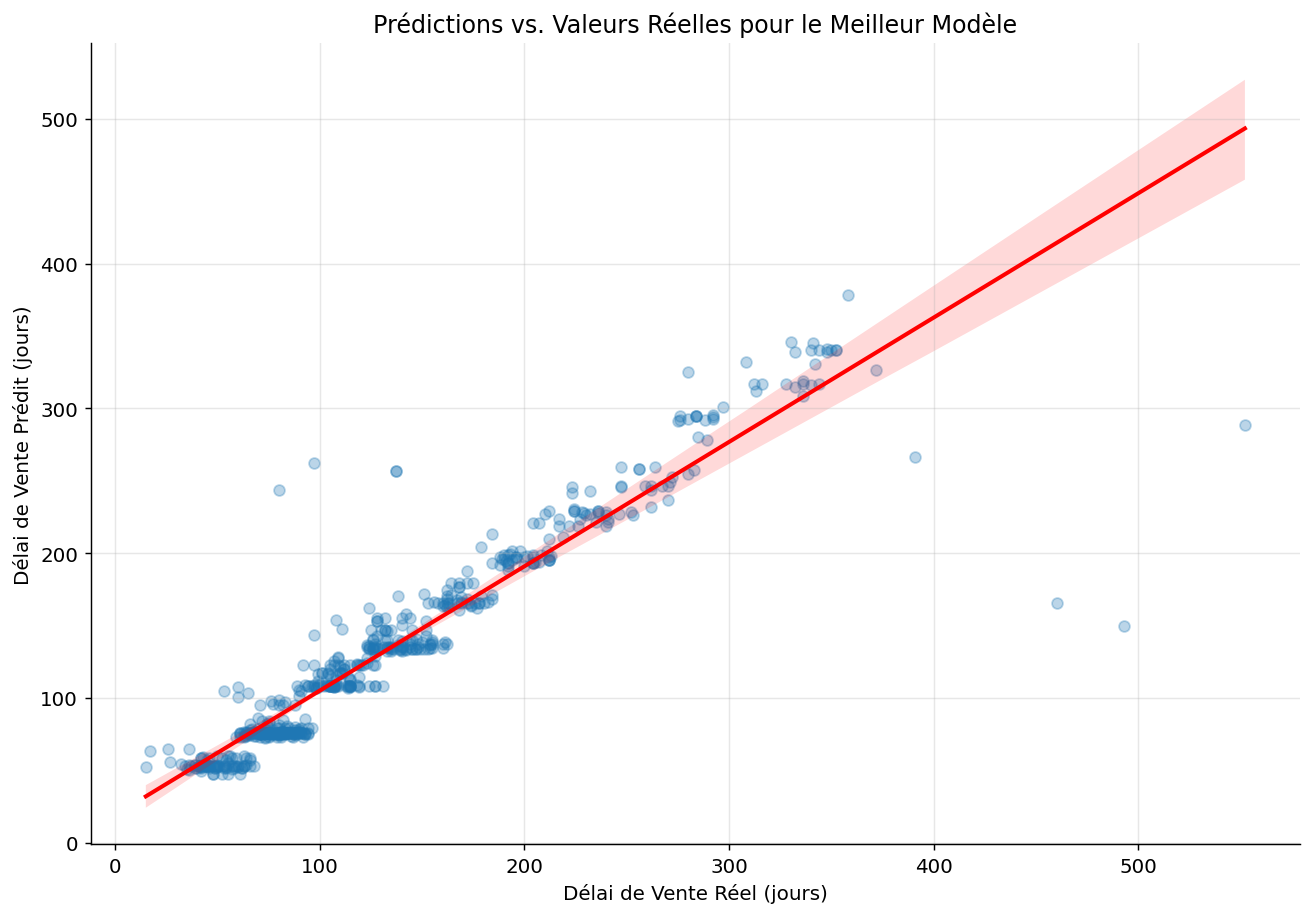

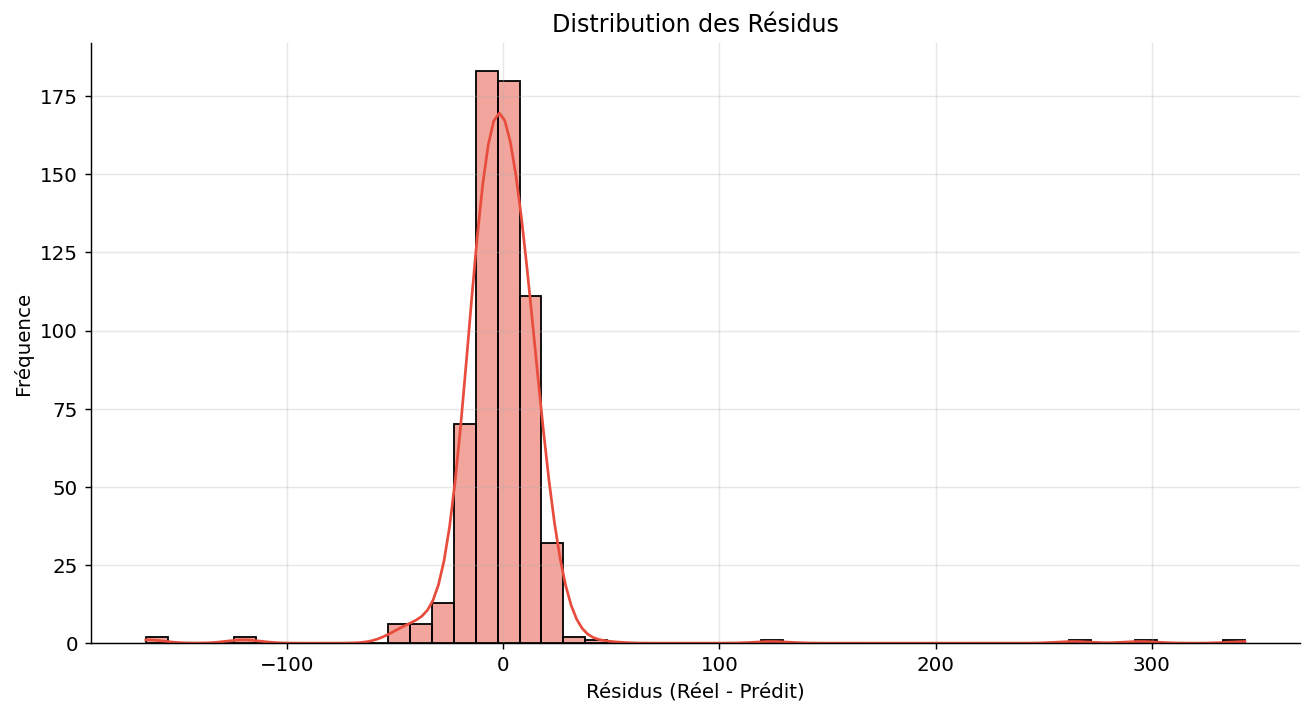

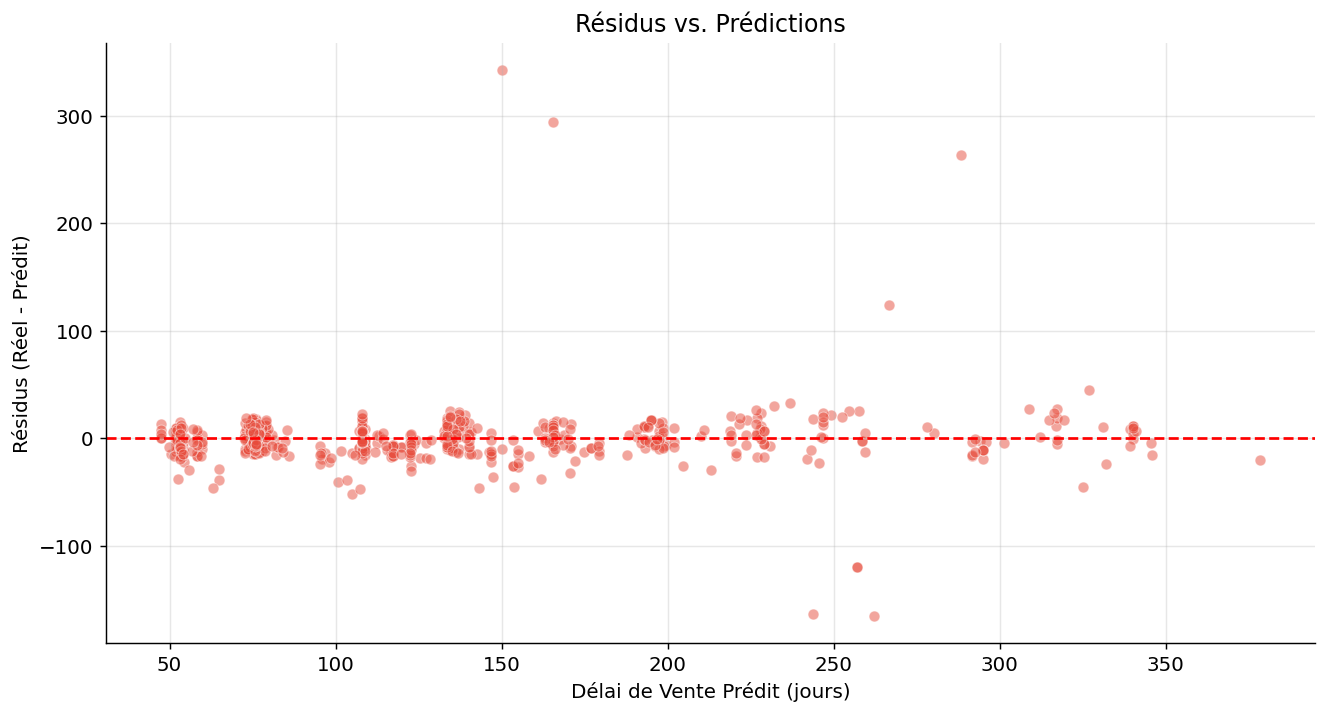

In [28]:
# Récupérer les prédictions du meilleur modèle
best_pred = best_pipeline.predict(X_test)

# Visualisation des prédictions vs. valeurs réelles
plt.figure(figsize=(12, 8))
sns.regplot(x=y_test, y=best_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Délai de Vente Réel (jours)')
plt.ylabel('Délai de Vente Prédit (jours)')
plt.title('Prédictions vs. Valeurs Réelles pour le Meilleur Modèle')
plt.grid(True)
plt.show()

# Visualisation des résidus
residuals = y_test - best_pred
plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True, bins=50, color=C_RED)
plt.title('Distribution des Résidus')
plt.xlabel('Résidus (Réel - Prédit)')
plt.ylabel('Fréquence')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x=best_pred, y=residuals, alpha=0.5, color=C_RED)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Délai de Vente Prédit (jours)')
plt.ylabel('Résidus (Réel - Prédit)')
plt.title('Résidus vs. Prédictions')
plt.grid(True)
plt.show()


## 8. Analyse par Segment

Cette section explore le délai de vente par segments clés (Type de bien, Ville, État, Standing, Source, Vendeur), offrant des insights métier.


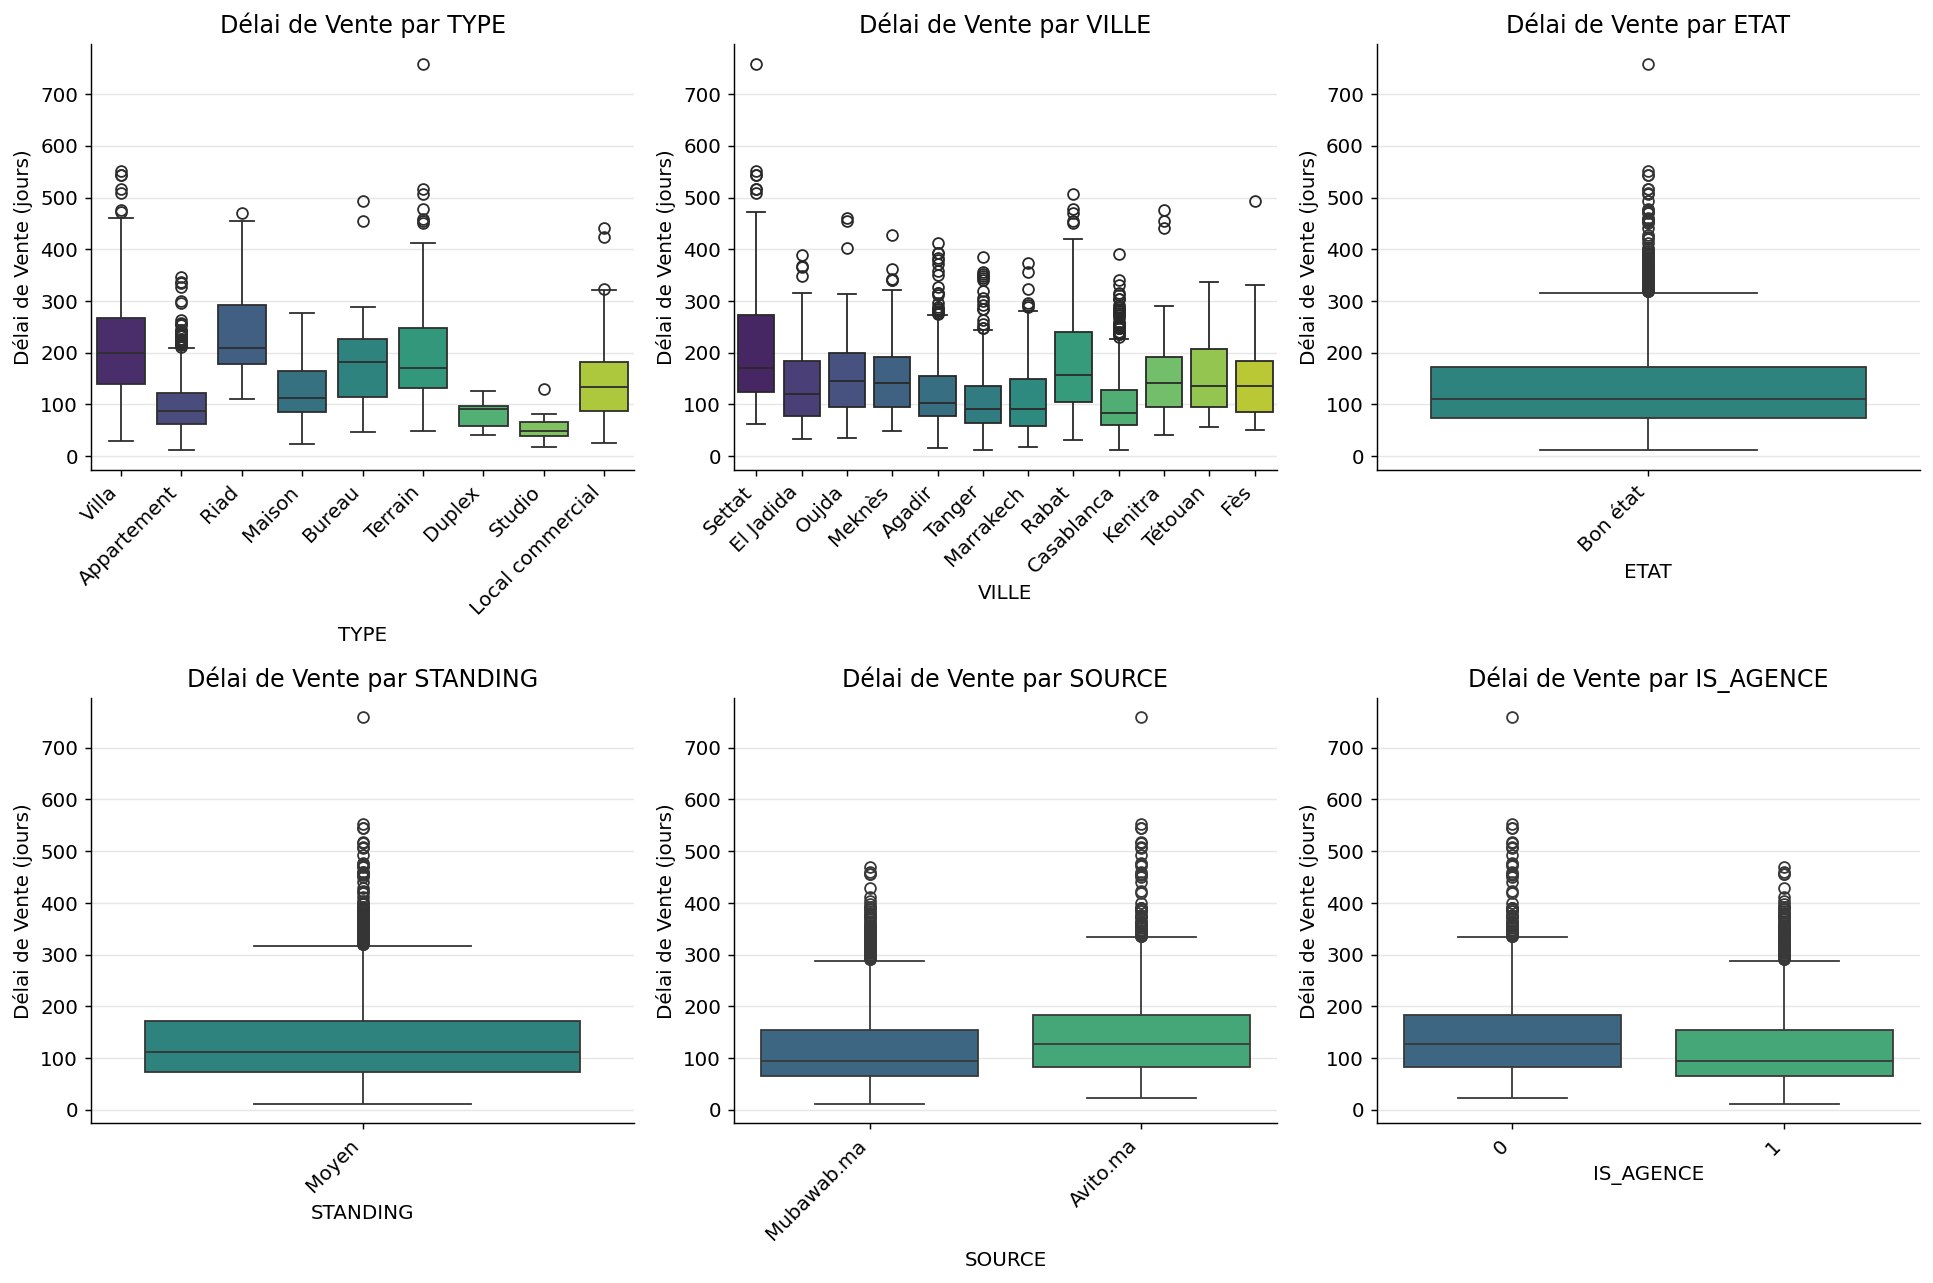


--- Analyse du Délai de Vente par Type de Bien ---
                  Nb_ventes  Delai_median  Delai_moyen
TYPE                                                  
Riad                     33         210.0   240.878788
Villa                   732         200.0   207.469945
Bureau                   26         183.0   184.230769
Terrain                 127         171.0   201.960630
Local commercial        187         134.0   143.048128
Maison                  213         113.0   123.779343
Duplex                   12          91.0    82.500000
Appartement            1687          87.0    95.912863
Studio                   40          48.5    53.575000

--- Analyse du Délai de Vente par Ville ---
            Nb_ventes  Delai_median  Delai_moyen
VILLE                                           
Settat            175         170.0   207.560000
Rabat             403         156.0   180.918114
Oujda             130         144.5   156.184615
Kenitra           107         142.0   154.934579
Mekn

In [29]:
segments = ['TYPE', 'VILLE', 'ETAT', 'STANDING', 'SOURCE', 'IS_AGENCE']

plt.figure(figsize=(15, 10))
for i, seg in enumerate(segments):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    sns.boxplot(x=seg, y='DELAI_VENTE', data=df.dropna(subset=['DELAI_VENTE']), palette='viridis')
    plt.title(f'Délai de Vente par {seg}')
    plt.xlabel(seg)
    plt.ylabel('Délai de Vente (jours)')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Exemple d'analyse pour un segment spécifique (ex: TYPE)
type_stats = df.dropna(subset=['DELAI_VENTE']).groupby('TYPE')['DELAI_VENTE'].agg(['count', 'median', 'mean']).sort_values(by='median', ascending=False)
type_stats.columns = ['Nb_ventes', 'Delai_median', 'Delai_moyen']
print("\n--- Analyse du Délai de Vente par Type de Bien ---")
print(type_stats.to_string())

# Exemple d'analyse pour un segment spécifique (ex: VILLE)
ville_stats = df.dropna(subset=['DELAI_VENTE']).groupby('VILLE')['DELAI_VENTE'].agg(['count', 'median', 'mean']).sort_values(by='median', ascending=False)
ville_stats.columns = ['Nb_ventes', 'Delai_median', 'Delai_moyen']
print("\n--- Analyse du Délai de Vente par Ville ---")
print(ville_stats.to_string())


## 9. Prédicteur Interactif

Créez un prédicteur interactif pour estimer le délai de vente d'une nouvelle annonce.


In [30]:
def predict_delai_vente(model_pipeline, data_input):
    # Créez un DataFrame à partir des données d'entrée
    input_df = pd.DataFrame([data_input])

    # Assurez-vous que toutes les colonnes nécessaires sont présentes, même avec NaN
    # Les colonnes manquantes seront gérées par le preprocessor (imputation/one-hot)
    all_expected_cols = NUM_FEATURES + CAT_FEATURES
    for col in all_expected_cols:
        if col not in input_df.columns:
            input_df[col] = np.nan

    # Réordonner les colonnes pour correspondre à l'entraînement
    input_df = input_df[all_expected_cols]

    # Faites la prédiction
    predicted_delai = model_pipeline.predict(input_df)[0]
    return max(0, round(predicted_delai))

# Exemple d'utilisation du prédicteur interactif
# Remplacer par des valeurs réelles pour tester
new_annonce = {
    'TYPE': 'Appartement',
    'VILLE': 'Casablanca',
    'QUARTIER': 'Maarif',
    'SURF_M2': 100,
    'CHAMBRES': 3,
    'PRIX_MAD': 1500000,
    'MAD_M2': 15000,
    'MOIS_LISTING': 6,
    'TRIMESTRE_LISTING': 2,
    'JOUR_SEMAINE': 2, # Mercredi
    'IS_AGENCE': 1,
    'ETAT': 'Bon état',
    'STANDING': 'Moyen',
    'SAISON': 'Été',
    'SOURCE': 'Mubawab.ma',
    'IS_NEUF': 0,
    'IS_RENOVER': 0,
    'IS_HAUT_STAND': 0,
    'LOG_PRIX': np.log1p(1500000),
    'LOG_SURFACE': np.log1p(100),
    'PRIX_REL_VILLE': 1.0 # Prix relatif médian pour la ville (nécessite un calcul dynamique ou valeur par défaut)
}

# Assurez-vous que le meilleur pipeline est toujours disponible
if 'best_pipeline' in locals():
    predicted_days = predict_delai_vente(best_pipeline, new_annonce)
    print(f"Le délai de vente prédit pour cette annonce est d'environ {predicted_days} jours.")
else:
    print("Le meilleur modèle n'a pas été trouvé. Veuillez exécuter la section de comparaison des modèles.")


Le délai de vente prédit pour cette annonce est d'environ 235 jours.


## 10. Export du Dataset Enrichi

Exportez le DataFrame `df` enrichi en fonctionnalités vers un fichier CSV pour une utilisation ultérieure ou un partage.


In [31]:
output_path = '/content/morocco_real_estate_enriched_final.csv'
df.to_csv(output_path, index=False)
print(f"✅ DataFrame enrichi exporté vers : {output_path}")


✅ DataFrame enrichi exporté vers : /content/morocco_real_estate_enriched_final.csv


## 4. Préparation des Features ML

Cette section prépare les données pour l'entraînement des modèles de Machine Learning. Elle inclut:
*   La définition des colonnes numériques et catégorielles.
*   La gestion des valeurs manquantes.
*   La mise à l'échelle des variables numériques.
*   L'encodage 'one-hot' des variables catégorielles.

In [22]:
# Définition des colonnes numériques et catégorielles
NUM_FEATURES = ['SURF_M2', 'CHAMBRES', 'PRIX_MAD', 'MAD_M2', 'LOG_PRIX', 'LOG_SURFACE', 'MOIS_LISTING', 'TRIMESTRE_LISTING', 'JOUR_SEMAINE', 'IS_AGENCE', 'IS_NEUF', 'IS_RENOVER', 'IS_HAUT_STAND', 'PRIX_REL_VILLE']
CAT_FEATURES = ['TYPE', 'VILLE', 'QUARTIER', 'ETAT', 'STANDING', 'SAISON', 'SOURCE']
TARGET = 'DELAI_VENTE'

# Filtrer le DataFrame pour ne garder que les colonnes pertinentes
df_model = df[NUM_FEATURES + CAT_FEATURES + [TARGET]].copy()

# Suppression des lignes où la variable cible est manquante
df_model.dropna(subset=[TARGET], inplace=True)

# Séparer les features (X) et la cible (y)
X = df_model[NUM_FEATURES + CAT_FEATURES]
y = df_model[TARGET]

# Création des pipelines de prétraitement
# Pipeline pour les variables numériques: Imputation par la médiane puis Standardisation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les variables catégorielles: Imputation par la valeur la plus fréquente puis One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinaison des pipelines avec ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUM_FEATURES),
        ('cat', categorical_transformer, CAT_FEATURES)
    ])

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Données prétraitées et divisées : {len(X_train)} échantillons d'entraînement, {len(X_test)} échantillons de test.")
print(f"   Forme de X_train: {X_train.shape}, Forme de y_train: {y_train.shape}")
print(f"   Forme de X_test: {X_test.shape}, Forme de y_test: {y_test.shape}")

✅ Données prétraitées et divisées : 2445 échantillons d'entraînement, 612 échantillons de test.
   Forme de X_train: (2445, 21), Forme de y_train: (2445,)
   Forme de X_test: (612, 21), Forme de y_test: (612,)


## 4. Préparation des Features ML

Cette section prépare les données pour l'entraînement des modèles de Machine Learning. Elle inclut:
*   La définition des colonnes numériques et catégorielles.
*   La gestion des valeurs manquantes.
*   La mise à l'échelle des variables numériques.
*   L'encodage 'one-hot' des variables catégorielles.

In [23]:
# Définition des colonnes numériques et catégorielles
NUM_FEATURES = ['SURF_M2', 'CHAMBRES', 'PRIX_MAD', 'MAD_M2', 'LOG_PRIX', 'LOG_SURFACE', 'MOIS_LISTING', 'TRIMESTRE_LISTING', 'JOUR_SEMAINE', 'IS_AGENCE', 'IS_NEUF', 'IS_RENOVER', 'IS_HAUT_STAND', 'PRIX_REL_VILLE']
CAT_FEATURES = ['TYPE', 'VILLE', 'QUARTIER', 'ETAT', 'STANDING', 'SAISON', 'SOURCE']
TARGET = 'DELAI_VENTE'

# Filtrer le DataFrame pour ne garder que les colonnes pertinentes
df_model = df[NUM_FEATURES + CAT_FEATURES + [TARGET]].copy()

# Suppression des lignes où la variable cible est manquante
df_model.dropna(subset=[TARGET], inplace=True)

# Séparer les features (X) et la cible (y)
X = df_model[NUM_FEATURES + CAT_FEATURES]
y = df_model[TARGET]

# Création des pipelines de prétraitement
# Pipeline pour les variables numériques: Imputation par la médiane puis Standardisation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les variables catégorielles: Imputation par la valeur la plus fréquente puis One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinaison des pipelines avec ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUM_FEATURES),
        ('cat', categorical_transformer, CAT_FEATURES)
    ])

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Données prétraitées et divisées : {len(X_train)} échantillons d'entraînement, {len(X_test)} échantillons de test.")
print(f"   Forme de X_train: {X_train.shape}, Forme de y_train: {y_train.shape}")
print(f"   Forme de X_test: {X_test.shape}, Forme de y_test: {y_test.shape}")

✅ Données prétraitées et divisées : 2445 échantillons d'entraînement, 612 échantillons de test.
   Forme de X_train: (2445, 21), Forme de y_train: (2445,)
   Forme de X_test: (612, 21), Forme de y_test: (612,)


## 4. Préparation des Features ML

Cette section prépare les données pour l'entraînement des modèles de Machine Learning. Elle inclut:
*   La définition des colonnes numériques et catégorielles.
*   La gestion des valeurs manquantes.
*   La mise à l'échelle des variables numériques.
*   L'encodage 'one-hot' des variables catégorielles.

In [24]:
# Définition des colonnes numériques et catégorielles
NUM_FEATURES = ['SURF_M2', 'CHAMBRES', 'PRIX_MAD', 'MAD_M2', 'LOG_PRIX', 'LOG_SURFACE', 'MOIS_LISTING', 'TRIMESTRE_LISTING', 'JOUR_SEMAINE', 'IS_AGENCE', 'IS_NEUF', 'IS_RENOVER', 'IS_HAUT_STAND', 'PRIX_REL_VILLE']
CAT_FEATURES = ['TYPE', 'VILLE', 'QUARTIER', 'ETAT', 'STANDING', 'SAISON', 'SOURCE']
TARGET = 'DELAI_VENTE'

# Filtrer le DataFrame pour ne garder que les colonnes pertinentes
df_model = df[NUM_FEATURES + CAT_FEATURES + [TARGET]].copy()

# Suppression des lignes où la variable cible est manquante
df_model.dropna(subset=[TARGET], inplace=True)

# Séparer les features (X) et la cible (y)
X = df_model[NUM_FEATURES + CAT_FEATURES]
y = df_model[TARGET]

# Création des pipelines de prétraitement
# Pipeline pour les variables numériques: Imputation par la médiane puis Standardisation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les variables catégorielles: Imputation par la valeur la plus fréquente puis One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinaison des pipelines avec ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUM_FEATURES),
        ('cat', categorical_transformer, CAT_FEATURES)
    ])

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Données prétraitées et divisées : {len(X_train)} échantillons d'entraînement, {len(X_test)} échantillons de test.")
print(f"   Forme de X_train: {X_train.shape}, Forme de y_train: {y_train.shape}")
print(f"   Forme de X_test: {X_test.shape}, Forme de y_test: {y_test.shape}")

✅ Données prétraitées et divisées : 2445 échantillons d'entraînement, 612 échantillons de test.
   Forme de X_train: (2445, 21), Forme de y_train: (2445,)
   Forme de X_test: (612, 21), Forme de y_test: (612,)


In [17]:
# Création d'une copie du DataFrame brut pour le nettoyage et l'ingénierie des fonctionnalités
df = df_raw.copy()

# --- Traitement des dates et calcul du délai de vente ---

# Conversion des colonnes de dates au format datetime
date_cols = ['DATE_LISTING', 'DATE_TRANSACTION', 'DATE_SOLD']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Calcul du DELAI_VENTE si manquant, basé sur DATE_LISTING et DATE_SOLD
# Si DELAI_VENTE est déjà présent et valide, on le conserve.
# Sinon, on le calcule à partir des dates.
df['DELAI_VENTE_CALC'] = (df['DATE_SOLD'] - df['DATE_LISTING']).dt.days

# Utilisation de la colonne DELAI_VENTE existente si non nulle, sinon celle calculée
df['DELAI_VENTE'] = df['DELAI_VENTE'].fillna(df['DELAI_VENTE_CALC'])

# Supprimer la colonne calculée temporaire
df = df.drop(columns=['DELAI_VENTE_CALC'])

# Remplacer les valeurs négatives ou nulles dans DELAI_VENTE par NaN (à imputer plus tard si nécessaire)
df.loc[df['DELAI_VENTE'] <= 0, 'DELAI_VENTE'] = np.nan

# --- Ingénierie des fonctionnalités temporelles ---

# Mois de mise en ligne
df['MOIS_LISTING'] = df['DATE_LISTING'].dt.month
# Trimestre de mise en ligne
df['TRIMESTRE_LISTING'] = df['DATE_LISTING'].dt.quarter
# Jour de la semaine de mise en ligne (0=Lundi, 6=Dimanche)
df['JOUR_SEMAINE'] = df['DATE_LISTING'].dt.dayofweek

# Saison de mise en ligne (simplifié pour l'exemple)
def get_saison(month):
    if month in [3, 4, 5]: return 'Printemps'
    if month in [6, 7, 8]: return 'Été'
    if month in [9, 10, 11]: return 'Automne'
    return 'Hiver'
df['SAISON'] = df['MOIS_LISTING'].apply(get_saison)

# --- Ingénierie des fonctionnalités catégorielles/binaires ---

# Indicateur si l'annonce est par une agence (simplifié: basé sur la présence de 'Agence' ou 'immobilier' dans Vendeur)
df['IS_AGENCE'] = df['VENDEUR'].apply(lambda x: 1 if 'Agence' in str(x) or 'Immobilier' in str(x) else 0)

# Indicateurs pour l'état du bien
df['IS_NEUF'] = df['ETAT'].apply(lambda x: 1 if str(x) == 'Neuf' else 0)
df['IS_RENOVER'] = df['ETAT'].apply(lambda x: 1 if str(x) == 'À rénover' else 0)

# Indicateur pour le standing du bien (Haut standing ou Luxe)
df['IS_HAUT_STAND'] = df['STANDING'].apply(lambda x: 1 if str(x) in ['Haut standing', 'Luxe'] else 0)

# --- Ingénierie des fonctionnalités numériques ---

# Convert relevant columns to numeric, coercing errors to NaN
df['PRIX_MAD'] = pd.to_numeric(df['PRIX_MAD'], errors='coerce')
df['SURF_M2'] = pd.to_numeric(df['SURF_M2'], errors='coerce')
df['MAD_M2'] = pd.to_numeric(df['MAD_M2'], errors='coerce') # Added this line

# Logarithme du prix et de la surface pour gérer l'asymétrie
df['LOG_PRIX'] = np.log1p(df['PRIX_MAD'])
df['LOG_SURFACE'] = np.log1p(df['SURF_M2'])

# Prix relatif à la ville (nécessite les prix médians par ville - supposons VILLES dict est défini)
# Use the VILLES dictionary that was in the kernel state
if 'VILLES' in locals():
    prix_medians_ville = {ville: data['m2_base'] for ville, data in VILLES.items()}
    df['PRIX_REL_VILLE'] = df.apply(lambda row: row['MAD_M2'] / prix_medians_ville.get(row['VILLE'], 1) if row['VILLE'] in prix_medians_ville else np.nan, axis=1)
else:
    print("Warning: 'VILLES' dictionary not found in kernel state. 'PRIX_REL_VILLE' will not be created.")
    # Fallback if VILLES is not defined (should not happen if notebook was run previously)
    df['PRIX_REL_VILLE'] = df['MAD_M2'] / df.groupby('VILLE')['MAD_M2'].transform('median')


# Nettoyage des valeurs aberrantes ou incohérentes pour les chambres
df.loc[df['CHAMBRES'] > 10, 'CHAMBRES'] = np.nan # Supposons qu'au-delà de 10 chambres c'est une aberration

# --- Affichage des informations après feature engineering ---
print(f"✅ DataFrame après nettoyage et ingénierie des fonctionnalités : {len(df)} annonces")
print("   Nouvelles colonnes créées :", [col for col in df.columns if col not in df_raw.columns])
print("   Aperçu (5 premières lignes) :")
print(df.head().to_string())

✅ DataFrame après nettoyage et ingénierie des fonctionnalités : 6142 annonces
   Nouvelles colonnes créées : ['MOIS_LISTING', 'TRIMESTRE_LISTING', 'JOUR_SEMAINE', 'SAISON', 'IS_AGENCE', 'IS_NEUF', 'IS_RENOVER', 'IS_HAUT_STAND', 'LOG_PRIX', 'LOG_SURFACE', 'PRIX_REL_VILLE']
   Aperçu (5 premières lignes) :
               ID                                            Titre annonce         TYPE    TXN   VILLE QUARTIER  SURF_M2 CHAMBRES  PRIX_MAD  MAD_M2 DATE_LISTING DATE_TRANSACTION  DATE_SOLD STATUS  DELAI_VENTE      SOURCE VENDEUR                                                                                                    URL                 Collecté le      ETAT STANDING  MOIS_LISTING  TRIMESTRE_LISTING  JOUR_SEMAINE     SAISON  IS_AGENCE  IS_NEUF  IS_RENOVER  IS_HAUT_STAND   LOG_PRIX  LOG_SURFACE  PRIX_REL_VILLE
10  MB-47B85FE166                           Appartement hay el khair 85 m2  Appartement  Vente  Settat   Centre       85        7    350000    4117   2026-02-20          